# Imports

In [18]:
'''
!pip install tensorflow
!pip install keras
!pip install librosa
!pip install torch
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install seaborn
'''

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import librosa
import librosa.display
import os
import seaborn as sns
from os import path
import skimage 
from skimage.filters import threshold_otsu
from sklearn.manifold import TSNE
import random


# Util Functions 

1. window_audio
    Load an audio file and slice it into fixed-length.

    Recordings vary widely in length, but the model requires fixed-size input, so each
    recording is split into many equal-length chunks rather than used whole. Windows are
    always exactly `window_sec` long; any leftover partial chunk at the end of the
    recording is discarded rather than padded, to avoid creating near-empty windows that
    could later distort energy filtering.



2. compute_window_energy
    Compute the RMS energy of an audio window.

    Used as an approximate for the question: does this window contain an actual
    bird vocalization, or just silence/background noise? This is not a
    validated call detector — there is no ground-truth label to check it against, and it
    can be diluted by a brief loud call surrounded by silence within the same window.

3. generate_spectrograms 
    Convert one audio recording into a set of labeled, energy-filtered mel spectrograms.

    Combines `window_audio` and `compute_window_energy`: slices the recording into
    windows, discards any window whose energy falls below `energy_threshold` (likely
    silence or background noise), and converts the surviving windows into mel
    spectrograms.

    `energy_threshold=0.01` was chosen by comparing candidate thresholds (0.01, 0.03,
    and an automatically computed Otsu threshold of 0.068, which is tested in later parts of the notebook) by how many whole recordings
    each one reduced to zero surviving windows; 0.068 silently discarded 38% of
    recordings, while 0.01 discarded under 1%.

    
    
    

In [19]:
#Cut everything to same length 
WINDOW_SIZE = 1.0 #seconds (as low as possible to dilute rms problem)
ENERGY_THRESHOLD = 0.01 #Based off of testing 
SPEC_HOP_LENGTH = 512

def window_audio(path, window_sec=WINDOW_SIZE, hop_sec=None): #loads in all windows at the same length
    y, sr = librosa.load(path, sr=None)
    window_length = int(window_sec * sr)
    audio_hop_length = int(hop_sec * sr) if hop_sec else window_length

    windows = []
    for start in range(0, len(y) - window_length + 1, audio_hop_length):
        windows.append(y[start:start + window_length])

    return windows, sr

def compute_window_energy(window):  #Uses RMS energy to compute energy of window
    return np.sqrt(np.mean(window ** 2)) 

def generate_spectrograms(path, window_sec=WINDOW_SIZE, hop_sec=0.5, energy_threshold=ENERGY_THRESHOLD, #
                            n_mels=128, n_fft=2048, hop_length=SPEC_HOP_LENGTH):
    windows, sr = window_audio(path, window_sec=window_sec, hop_sec=hop_sec)
    spectrograms = []
    for window in windows:
        if compute_window_energy(window) < energy_threshold:
            continue
        mel_spec = librosa.feature.melspectrogram(y=window, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length)
        mel_db = librosa.power_to_db(mel_spec, ref=np.max)
        spectrograms.append(mel_db)
    return spectrograms, sr

# EDA

## Load Metadata

Loads the Kaggle metadata CSV. Each row describes one recording: its species (genus,
species, English common name), country of origin, vocalization `type` (song/call/etc.),
and the `file_id` used to locate the corresponding audio file on disk.

In [20]:
metadata = pd.read_csv('data/birdsong_metadata.csv')
print(type(metadata))
metadata = pd.read_csv('data/birdsong_metadata.csv')
print(metadata.head())
print(metadata.info())
print(metadata.columns.tolist())

#Note: 3 nulls in longitude/lagitude 

print(os.listdir('data/songs/songs')[:10])
print(len(os.listdir('data/songs/songs')))

<class 'pandas.DataFrame'>
   file_id         genus    species   english_cname who_provided_recording  \
0   132608      Acanthis    flammea  Common Redpoll         Jarek Matusiak   
1   132611      Acanthis    flammea  Common Redpoll         Jarek Matusiak   
2    35068      Acanthis    flammea  Common Redpoll             Sander Bot   
3    82715  Acrocephalus  palustris   Marsh Warbler         Dougie Preston   
4    64685  Acrocephalus  palustris   Marsh Warbler         Dougie Preston   

          country  latitude  longitute                     type  \
0          Poland   50.7932    15.4995       female, male, song   
1          Poland   50.7932    15.4995  flight call, male, song   
2     Netherlands   52.8176     6.4326               call, song   
3  United Kingdom   60.3539    -1.2689                     Song   
4  United Kingdom   60.3539    -1.2689                     Song   

                                             license  
0  http://creativecommons.org/licenses/by-nc-s

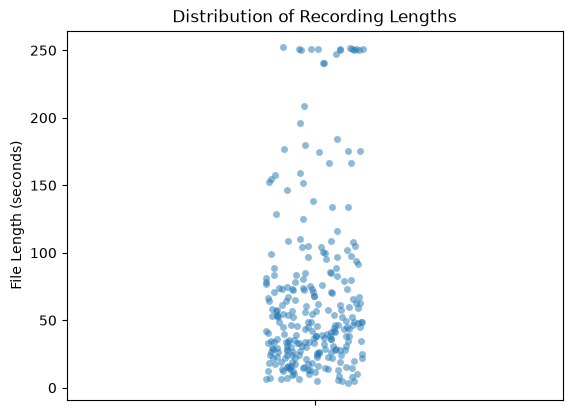

                           mean         std         min         max  \
english_cname                                                         
Sedge Warbler        169.769569  140.487016    7.549161  250.958141   
Willow Warbler       104.851043  124.084445   19.343787  247.170385   
Common Blackbird     106.971277  125.599164   24.345896  251.506712   
Common Pheasant      122.677453  115.301182   31.163855  252.179751   
Song Thrush          118.763424  114.712537   43.343787  250.775283   
...                         ...         ...         ...         ...   
Common Snipe          26.601209    3.727826   22.308345   29.021814   
Marsh Warbler         15.577687    2.390930   12.930612   17.580408   
European Greenfinch   33.332018    2.026637   31.111610   35.082222   
Long-tailed Tit       27.690234    2.028807   25.391791   29.231791   
Corn Bunting         250.862358    0.313832  250.540181  251.167120   

                          range  
english_cname                    
Sedge Wa

In [21]:
#Find the distribution of metadata recordings to see whether file length needs to be standardized
file_length = []
for idx, row in metadata.iterrows() :
    filepath = f"data/songs/songs/xc{row['file_id']}.flac"
    try: 
        file_length.append(librosa.get_duration(path=filepath))
    except Exception as e: 
        print(f"Error processing file {filepath}: {repr(e)}")
        file_length.append(None)

metadata['file_length'] = file_length
metadata.to_csv('data/file_length.csv', index=False)

sns.stripplot(data=metadata, y='file_length', alpha=0.5)
plt.title('Distribution of Recording Lengths')
plt.ylabel('File Length (seconds)')
plt.show()

species_stats = metadata.groupby('english_cname')['file_length'].agg(['mean', 'std', 'min', 'max'])
species_stats['range'] = species_stats['max'] - species_stats['min']
print(species_stats.sort_values('range', ascending=False))
species_stats.to_csv('data/species_stats.csv', index=True)

In [22]:
#There are only three recordings per species, which makes the classification problem incredibly difficult


In [23]:
#Make sure Sample Rates are all consistent
sample_rates = []
for i in metadata['file_id'] :
    try: 
        sample_rates.append(librosa.get_samplerate(f"data/songs/songs/xc{i}.flac"))
    except Exception as e:
        print(f"Error processing file xc{i}.flac: {repr(e)}")
        sample_rates.append(None)

metadata['sample_rate'] = sample_rates
print(metadata['sample_rate'])

    

0      44100
1      44100
2      44100
3      44100
4      44100
       ...  
259    44100
260    44100
261    44100
262    44100
263    44100
Name: sample_rate, Length: 264, dtype: int64


In [24]:
#generate Mel Spectogram 

for row in metadata.iterrows():
    file_id = row[1]['file_id']
    path = f"data/songs/songs/xc{file_id}.flac"
    y, sr = librosa.load(path, sr=None)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, n_fft=2048, hop_length=SPEC_HOP_LENGTH)

    mel_db = librosa.power_to_db(mel_spec, ref=np.max)


## Filtering to Usable Recordings

Two filters are applied to the metadata before any audio processing:

1. Keep only recordings whose `type` field mentions "song" (alone or combined with
   "call"). A stricter "song only" filter was considered and rejected — it would drop
   to 62 species (from 74), a larger loss than the label imprecision it avoids.
2. Keep only species with at least 2 remaining recordings — the minimum needed to form
   a same-species pair from two *different* recordings, required for both triplet
   training and few-shot evaluation.

In [25]:
#Filter 1 - type must include song 

t = metadata['type'].str.lower()
has_song = t.str.contains('song')
song_inclusive = metadata[has_song].copy()

#Filter 2 - Keep Species with over 2 recordings to set up for triplet pairs 

species_counts = song_inclusive['english_cname'].value_counts()
valid_species = species_counts[species_counts >= 2].index

metadata_filtered = song_inclusive[song_inclusive['english_cname'].isin(valid_species)].copy()

print("After species-count filter: " + str(len(metadata_filtered)) + " recordings, " + str(metadata_filtered['english_cname'].nunique()) + " species")
metadata_filtered.to_csv('data/metadata_filtered.csv', index=False)

After species-count filter: 218 recordings, 74 species


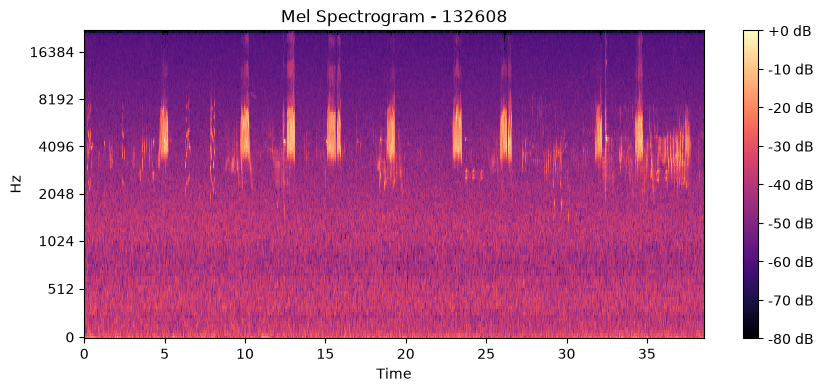

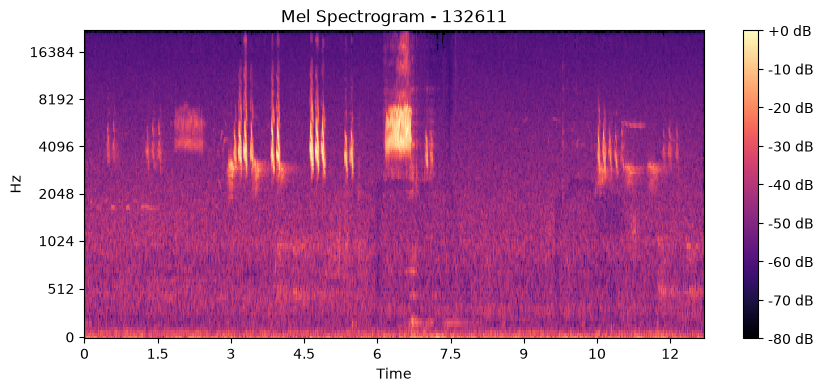

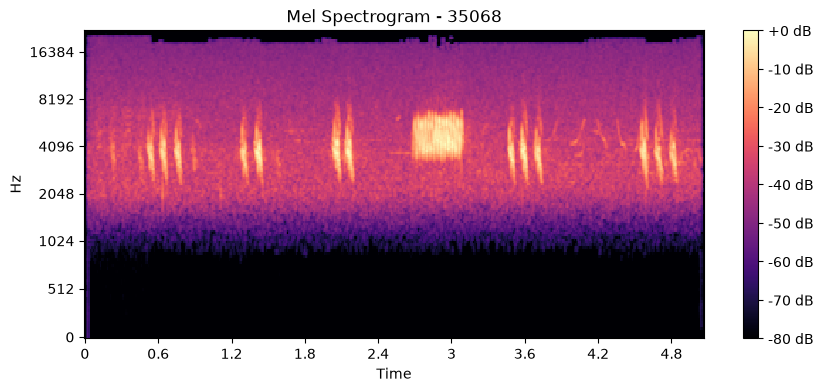

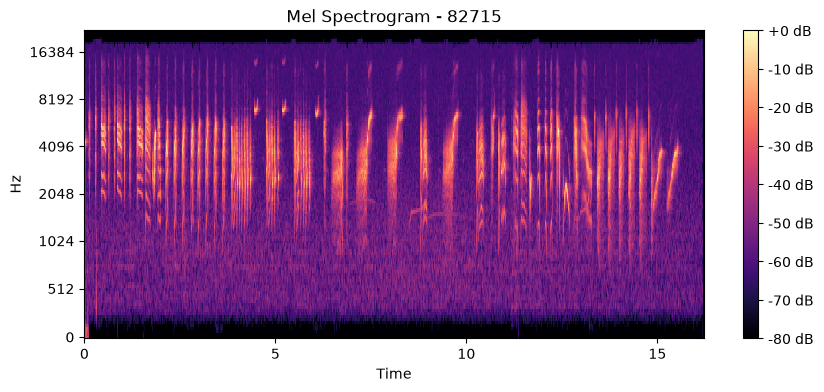

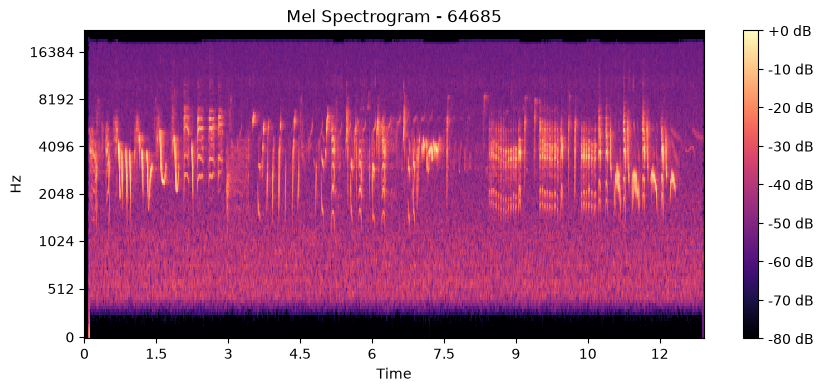

In [26]:
#Test spectograms for metadata_filtered
for row in metadata_filtered.head(5).iterrows():
    file_id = row[1]['file_id']
    path = f"data/songs/songs/xc{file_id}.flac"
    y, sr = librosa.load(path, sr=None)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, n_fft=2048, hop_length=SPEC_HOP_LENGTH)

    mel_db = librosa.power_to_db(mel_spec, ref=np.max)

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mel_db, sr=sr, hop_length=SPEC_HOP_LENGTH, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Mel Spectrogram - {file_id}')
    plt.show()

## Choosing the Energy Threshold

There's no ground-truth label distinguishing silence from vocalization at the sample
level, so no threshold is analytically "correct" — this was a judgment call, made using
several kinds of evidence together: a full-dataset histogram of window energies, an
automatic threshold (Otsu's method), and — most decisively — how many recordings each
candidate threshold reduced to *zero* surviving windows:

| Threshold | Recordings with 0 survivors |
|---|---|
| 0.01 | 2 / 218 |
| 0.03 | 30 / 218 |
| 0.068 (Otsu) | 82 / 218 |

Otsu's automatic threshold  discarded over a third of all recordings, which 
undermines the earlier decision to require at least 2 recordings per species. `0.01`
was chosen to avoid this  data loss, accepting in exchange that some noisy,
non-vocal windows may occasionally pass the filter.

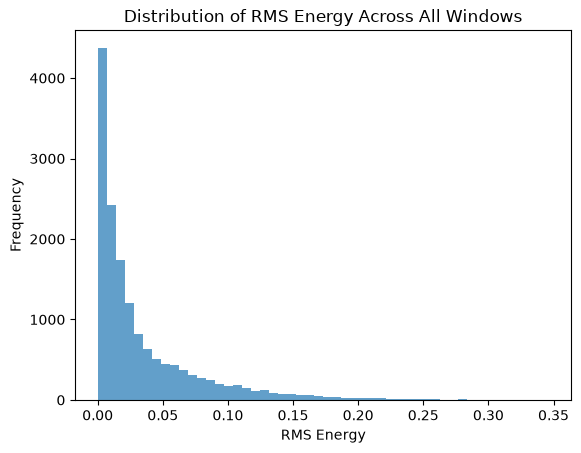

[0.00199329 0.004514   0.0074893  0.01168425 0.01739063 0.02442335
 0.03705973 0.0582991  0.09378265]


In [27]:
#Compute RMS energies across all windows to define ENERGY_THRESHOLD 

all_energies = []
for row in metadata_filtered.iterrows():
    filepath = f"data/songs/songs/xc{row[1]['file_id']}.flac"
    try: 
        windows, sr = window_audio(filepath, window_sec=WINDOW_SIZE)
        all_energies.extend([compute_window_energy(window) for window in windows])
    except Exception as e:
        print(f"Error processing file {filepath}: {repr(e)}")

plt.hist(all_energies, bins=50, alpha=0.7)
plt.xlabel('RMS Energy')
plt.ylabel('Frequency')
plt.title('Distribution of RMS Energy Across All Windows')
plt.show()

print(np.percentile(all_energies, [10,20,30,40,50,60,70,80,90]))



In [28]:
#Use Otsu's method to find optimal threshold for energy filtering
energies_array = np.array(all_energies)
otsu_threshold = threshold_otsu(energies_array)
print(f"Otsu's threshold for RMS energy: {otsu_threshold}")

Otsu's threshold for RMS energy: 0.06561240553855896


In [29]:
#Test energy filtering thresholds 
results = {}
for threshold in [0.01, 0.03, otsu_threshold]:
    per_file_counts = []
    for idx, row in metadata_filtered.iterrows():
        filepath = f"data/songs/songs/xc{row['file_id']}.flac"
        try:
            spectrograms, sr = generate_spectrograms(filepath, window_sec=WINDOW_SIZE, energy_threshold=threshold)
            per_file_counts.append(len(spectrograms))
        except Exception as e:
            continue
    results[threshold] = per_file_counts
    counts_series = pd.Series(per_file_counts)
    print(f"--- Threshold {threshold:.4f} ---")
    print(counts_series.describe())
    print(f"Files with 0 surviving windows: {(counts_series == 0).sum()} out of {len(counts_series)}")
    print()

--- Threshold 0.0100 ---
count    218.000000
mean      89.541284
std      107.225507
min        0.000000
25%       28.000000
50%       54.500000
75%      102.000000
max      500.000000
dtype: float64
Files with 0 surviving windows: 4 out of 218

--- Threshold 0.0300 ---
count    218.000000
mean      49.266055
std       75.243463
min        0.000000
25%        6.000000
50%       22.000000
75%       63.750000
max      480.000000
dtype: float64
Files with 0 surviving windows: 35 out of 218

--- Threshold 0.0656 ---
count    218.000000
mean      24.504587
std       57.008872
min        0.000000
25%        0.000000
50%        4.000000
75%       25.500000
max      473.000000
dtype: float64
Files with 0 surviving windows: 87 out of 218



## Generating the Full Preprocessed Dataset

Applies `generate_spectrograms` to every recording in the filtered metadata, turning
225 audio files into thousands of individual, labeled spectrogram windows. For each
row in `metadata_filtered`, the corresponding audio file is loaded, windowed, filtered
by energy, and converted to spectrograms; each surviving spectrogram is stored alongside
its species label (`all_labels`) and source recording (`all_file_ids`). Tracking the
source recording matters for later steps: triplet sampling prefers to draw a positive
example from a different recording than the anchor, to avoid the model learning
recording-specific artifacts instead of species identity.


In [ ]:
#Process files from metadata_filtered to generate spectrograms and labels for model training

all_spectrograms = []
all_labels = []
all_file_ids = []

for idx, row in metadata_filtered.iterrows():
    filepath = f"data/songs/songs/xc{row['file_id']}.flac"
    try:
        spectrograms, sr = generate_spectrograms(filepath, window_sec=WINDOW_SIZE, energy_threshold=0.01)
    except Exception as e:
        print(f"Error on {filepath}: {repr(e)}")
        continue
    for spec in spectrograms:
        all_spectrograms.append(spec)
        all_labels.append(row['english_cname'])
        all_file_ids.append(row['file_id'])

print(f"Amount of spectrograms: {len(all_spectrograms)}")
print(all_spectrograms[0].shape)

Amount of spectrograms: 19520
(128, 87)


## Embedding Network (CNN)

A small convolutional network that maps one spectrogram window to a fixed-length
embedding vector. Three convolution + max-pooling blocks extract
acoustic patterns, followed by adaptive average pooling (so the
network isn't tied to one exact spectrogram width) and a final linear layer producing
the embedding itself. 

In [ ]:
class EmbeddingNet(nn.Module):
    def __init__(self, embedding_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))   
        )
        self.fc = nn.Linear(64, embedding_dim)

    def forward(self, x):
        x = self.conv(x)          # shape: (batch, 64, 1, 1)
        x = x.view(x.size(0), -1) # flatten to (batch, 64)
        x = self.fc(x)            # shape: (batch, embedding_dim)
        return x

## Train / Validation / Test Split

Species are randomly split 70/15/15 into
train/validation/test sets. This is deliberate because the goal is to measure whether the model generalizes to species during training, so no
species may appear in more than one split. Splitting at the recording or window level
instead would let the model "cheat" by recognizing a species it had already partially
seen.

In [ ]:
#Training/Test/Val Split

unique_species = list(set(all_labels))
random.seed(42)
random.shuffle(unique_species)

n_species = len(unique_species)
n_train = int(n_species * 0.7)
n_val = int(n_species * 0.15)

train_species = unique_species[:n_train]
val_species = unique_species[n_train:n_train + n_val]
test_species = unique_species[n_train + n_val:]

print(f"Train: {len(train_species)} species")
print(f"Val: {len(val_species)} species")
print(f"Test: {len(test_species)} species")

#Confirm no overlap

print("Train/Val overlap:", set(train_species) & set(val_species))
print("Train/Test overlap:", set(train_species) & set(test_species))
print("Val/Test overlap:", set(val_species) & set(test_species))

Train: 51 species
Val: 11 species
Test: 12 species
Train/Val overlap: set()
Train/Test overlap: set()
Val/Test overlap: set()


## Triplet Sampling Dataset

`TripletBirdsongDataset` generates one training example at a time: an anchor, a
positive, and a negative. Species are sampled uniformly at random before
selecting individual windows, so species with more surviving windows (from longer or
noisier recordings) don't dominate training. Preferring cross-recording positive pairs
is intended to push the model toward learning species identity rather than
recording-specific artifacts like background noise or microphone characteristics.

In [ ]:
class TripletBirdsongDataset(Dataset):
    def __init__(self, spectrograms, labels, file_ids, species_list):
        """
        spectrograms: list of 2D numpy arrays (all_spectrograms)
        labels: list of species names, same length (all_labels)
        file_ids: list of recording IDs, same length (all_file_ids)
        species_list: which species this dataset is allowed to sample from (e.g. train_species)
        """
        self.species_list = list(species_list)

        # organize spectrograms by species -> list of (spectrogram, file_id)
        self.by_species = {sp: [] for sp in self.species_list}
        for spec, label, fid in zip(spectrograms, labels, file_ids):
            if label in self.by_species:
                self.by_species[label].append((spec, fid))

    def __len__(self):
        # somewhat arbitrary for triplet sampling - defines how many triplets count as "one epoch"
        return sum(len(v) for v in self.by_species.values())

    def __getitem__(self, idx):
        # species-level sampling: pick two DIFFERENT species uniformly at random
        species_a, species_b = random.sample(self.species_list, 2)

        anchor_pool = self.by_species[species_a]
        negative_pool = self.by_species[species_b]

        # cross-recording positive: prefer anchor/positive from different file_ids
        anchor_spec, anchor_fid = random.choice(anchor_pool)
        candidates = [x for x in anchor_pool if x[1] != anchor_fid]
        positive_spec, _ = random.choice(candidates) if candidates else random.choice(anchor_pool)

        negative_spec, _ = random.choice(negative_pool)

        def to_tensor(spec):
            return torch.tensor(spec, dtype=torch.float32).unsqueeze(0)  # add channel dim -> (1, H, W)

        return to_tensor(anchor_spec), to_tensor(positive_spec), to_tensor(negative_spec)

## Training

Trains the embedding network using triplet loss: for each anchor/positive/negative
triplet, the loss pushes the anchor's embedding closer to the positive's and farther
from the negative's, by at least a fixed margin. Trained for 50 epochs with the Adam
optimizer; training loss dropped from 0.75 to 0.05. and began leveling off toward the
end, indicating the model was close to convergence.

In [ ]:
train_dataset = TripletBirdsongDataset(all_spectrograms, all_labels, all_file_ids, train_species)
print(f"Dataset built. Number of species with data: {len(train_dataset.by_species)}")

# check none of the training species ended up with zero spectrograms
empty_species = [sp for sp, items in train_dataset.by_species.items() if len(items) == 0]
print(f"Species with 0 spectrograms: {empty_species}")

#Test actual triplet

anchor, positive, negative = train_dataset[0]
print("Anchor shape:", anchor.shape)
print("Positive shape:", positive.shape)
print("Negative shape:", negative.shape)

print(f"Total spectrograms: {len(all_spectrograms)}")
print(f"Spectrogram shape: {all_spectrograms[0].shape}")
print(f"Train species: {len(train_species)}, Val: {len(val_species)}, Test: {len(test_species)}")

Dataset built. Number of species with data: 51
Species with 0 spectrograms: []
Anchor shape: torch.Size([1, 128, 87])
Positive shape: torch.Size([1, 128, 87])
Negative shape: torch.Size([1, 128, 87])
Total spectrograms: 19520
Spectrogram shape: (128, 87)
Train species: 51, Val: 11, Test: 12


In [ ]:
#Triplet Loss 

triplet_loss = nn.TripletMarginLoss(margin=1.0)


In [ ]:
train_dataset = TripletBirdsongDataset(all_spectrograms, all_labels, all_file_ids, train_species)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

model = EmbeddingNet(embedding_dim=64)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 50
for epoch in range(n_epochs):
    total_loss = 0
    for anchor, positive, negative in train_loader:
        optimizer.zero_grad()
        a_embed = model(anchor)
        p_embed = model(positive)
        n_embed = model(negative)

        loss = triplet_loss(a_embed, p_embed, n_embed)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/50, Loss: 0.8193
Epoch 2/50, Loss: 0.6076
Epoch 3/50, Loss: 0.4858
Epoch 4/50, Loss: 0.4181
Epoch 5/50, Loss: 0.3499
Epoch 6/50, Loss: 0.3178
Epoch 7/50, Loss: 0.2822
Epoch 8/50, Loss: 0.2588
Epoch 9/50, Loss: 0.2450
Epoch 10/50, Loss: 0.2153
Epoch 11/50, Loss: 0.1982
Epoch 12/50, Loss: 0.1839
Epoch 13/50, Loss: 0.1816
Epoch 14/50, Loss: 0.1621
Epoch 15/50, Loss: 0.1537
Epoch 16/50, Loss: 0.1491
Epoch 17/50, Loss: 0.1351
Epoch 18/50, Loss: 0.1348
Epoch 19/50, Loss: 0.1262
Epoch 20/50, Loss: 0.1137
Epoch 21/50, Loss: 0.1132
Epoch 22/50, Loss: 0.1107
Epoch 23/50, Loss: 0.1067
Epoch 24/50, Loss: 0.1024
Epoch 25/50, Loss: 0.1016
Epoch 26/50, Loss: 0.0886
Epoch 27/50, Loss: 0.0909
Epoch 28/50, Loss: 0.0898
Epoch 29/50, Loss: 0.0922
Epoch 30/50, Loss: 0.0855
Epoch 31/50, Loss: 0.0829
Epoch 32/50, Loss: 0.0857
Epoch 33/50, Loss: 0.0751
Epoch 34/50, Loss: 0.0731
Epoch 35/50, Loss: 0.0726
Epoch 36/50, Loss: 0.0719
Epoch 37/50, Loss: 0.0686
Epoch 38/50, Loss: 0.0658
Epoch 39/50, Loss: 0.

## Few-Shot Evaluation

Tests whether the embedding space generalizes to species the model never saw during
training. For each trial: one reference example of a held-out species is compared
against a true query. The model is scored correct if the query lands closer
to the true reference than to the distractor in embedding space, which is the same distance
metric (Euclidean) used by the triplet loss during training. Random guessing would
score ~50%; the trained model reaches roughly 60-71% depending on which species happen
to fall into the validation vs. test split.

In [ ]:
model.eval()

def get_embedding(model, spectrogram):
    with torch.no_grad():
        tensor = torch.tensor(spectrogram, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1, 1, H, W)
        embedding = model(tensor)
    return embedding.squeeze(0).numpy()  # return as 1D numpy array  

test_dataset =  TripletBirdsongDataset(all_spectrograms, all_labels, all_file_ids, test_species)

def run_few_shot_eval(model, species_list, dataset, n_trials=200):
    correct = 0
    total = 0
    for i in range(n_trials):
        species_a, species_b = random.sample(species_list, 2)

        pool_a = dataset.by_species[species_a]
        pool_b = dataset.by_species[species_b]

        ref_spec, ref_fid = random.choice(pool_a)

        query_candidates = []
        for x in pool_a:
            if x[1] != ref_fid:
                query_candidates.append(x)

        if not query_candidates:
            continue
        query_spec, query_fid = random.choice(query_candidates)

        distractor_spec, distractor_fid = random.choice(pool_b)

        ref_embed = get_embedding(model, ref_spec)
        query_embed = get_embedding(model, query_spec)
        distractor_embed = get_embedding(model, distractor_spec)

        dist_to_true = np.linalg.norm(ref_embed - query_embed)
        dist_to_distractor = np.linalg.norm(ref_embed - distractor_embed)

        if dist_to_true < dist_to_distractor:
            correct += 1
        total += 1

    accuracy = correct / total
    print(f"Few-shot accuracy: {correct}/{total} = {accuracy:.2%}")
    return accuracy



In [ ]:
# your val baseline, for the first time:
val_dataset = TripletBirdsongDataset(all_spectrograms, all_labels, all_file_ids, val_species)
print('Val Accuracy Evaluation:')
val_accuracy = run_few_shot_eval(model, val_species, val_dataset, n_trials=1000)

# later, to re-check test (only once, at the very end):
print('Test Accuracy Evaluation:')
test_accuracy = run_few_shot_eval(model, test_species, test_dataset, n_trials=1000)

Val Accuracy Evaluation:
Few-shot accuracy: 601/1000 = 60.10%
Test Accuracy Evaluation:
Few-shot accuracy: 649/916 = 70.85%


## Visualizing the Embedding Space

Compresses the 64-dimensional embeddings of all held-out test-species windows down to
2 dimensions using t-SNE, which tries to preserve relative distances from the original
space. Points are colored by species. Most species form visually distinct clusters,
consistent with the few-shot accuracy result; a few species split into multiple
sub-clusters (which may reflect per-recording characteristics such as background noise,
individual bird) rather than pure species identity. This is a limitation of expanding
few recordings into many windows via a sliding window.

Total embeddings: 2246, from 12 species


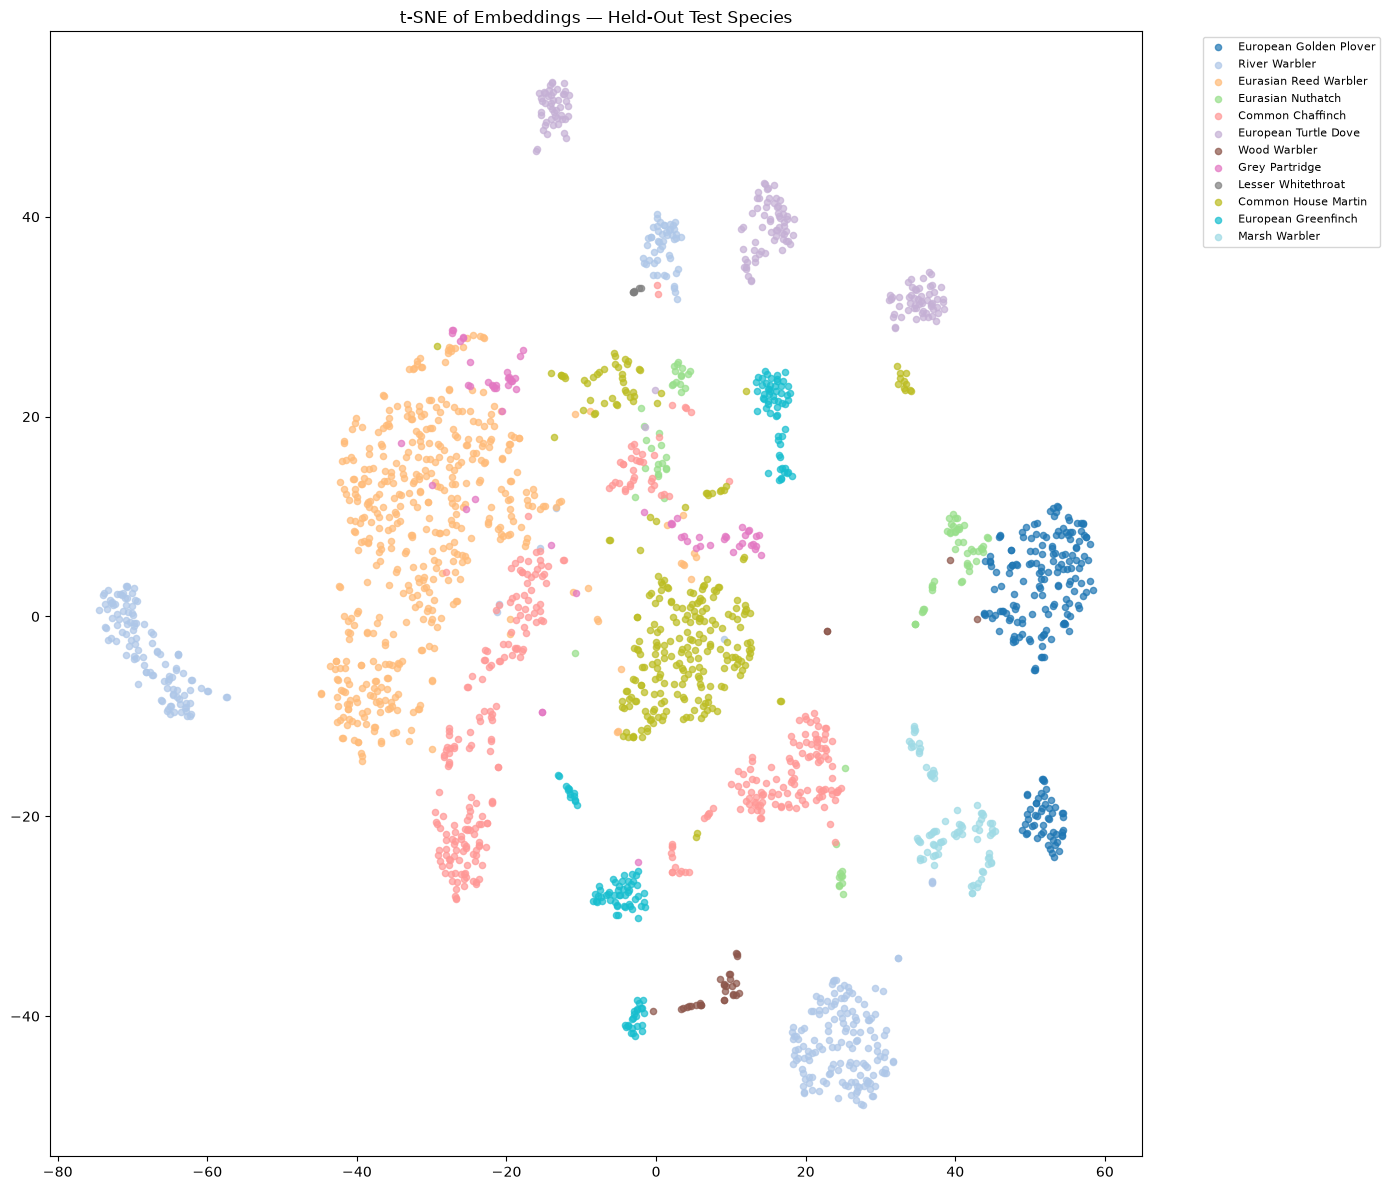

In [ ]:
test_embeddings = []
test_labels_list = []

for species in test_species: 
    pool = test_dataset.by_species[species]
    for spec, fid in pool: 
        embedd = get_embedding(model, spec)
        test_embeddings.append(embedd)
        test_labels_list.append(species)

test_embeddings = np.array(test_embeddings)

print(f"Total embeddings: {len(test_embeddings)}, from {len(set(test_labels_list))} species")

tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(test_embeddings) - 1))

embeddings_2d = tsne.fit_transform(test_embeddings)

plt.figure(figsize=(14,12))
unique_species = list(set(test_labels_list))
colors = plt.cm.tab20(np.linspace(0,1, len(unique_species)))

for species, color in zip(unique_species, colors):
    mask = [label == species for label in test_labels_list]
    points = embeddings_2d[mask]
    plt.scatter(points[:, 0], points[:, 1], label=species, color=color, alpha=0.7, s=20)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.title('t-SNE of Embeddings — Held-Out Test Species')
plt.tight_layout()
plt.savefig('outputs/tsne_test_species.png', dpi=150, bbox_inches='tight')
plt.show()

## Saving Trained Model

In [ ]:
os.makedirs('outputs', exist_ok=True)
torch.save(model.state_dict(), 'outputs/model_5.pt')